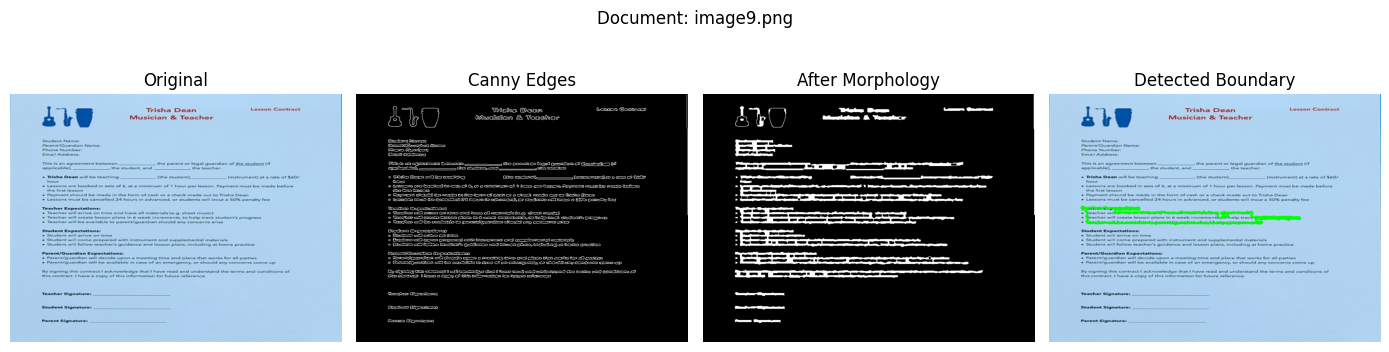

Processed: image9.png -> saved to output/detected_image9.png


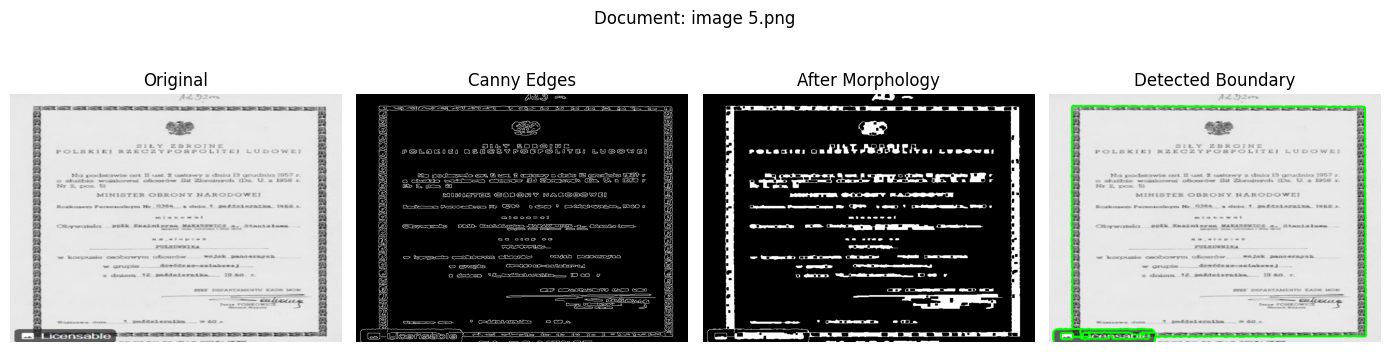

Processed: image 5.png -> saved to output/detected_image 5.png


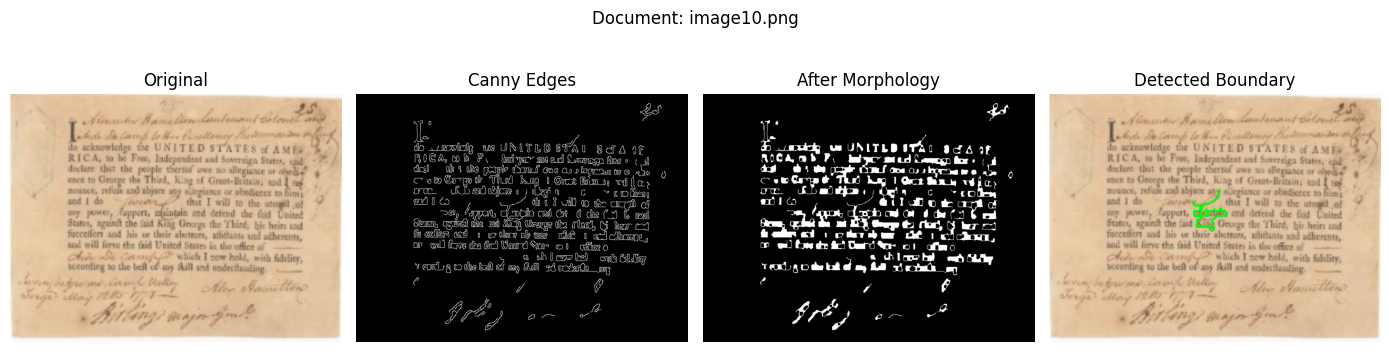

Processed: image10.png -> saved to output/detected_image10.png


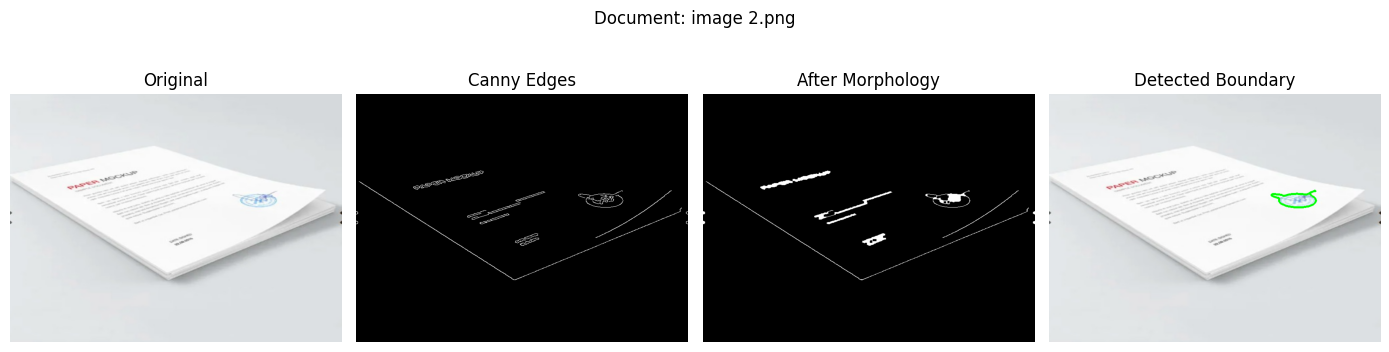

Processed: image 2.png -> saved to output/detected_image 2.png


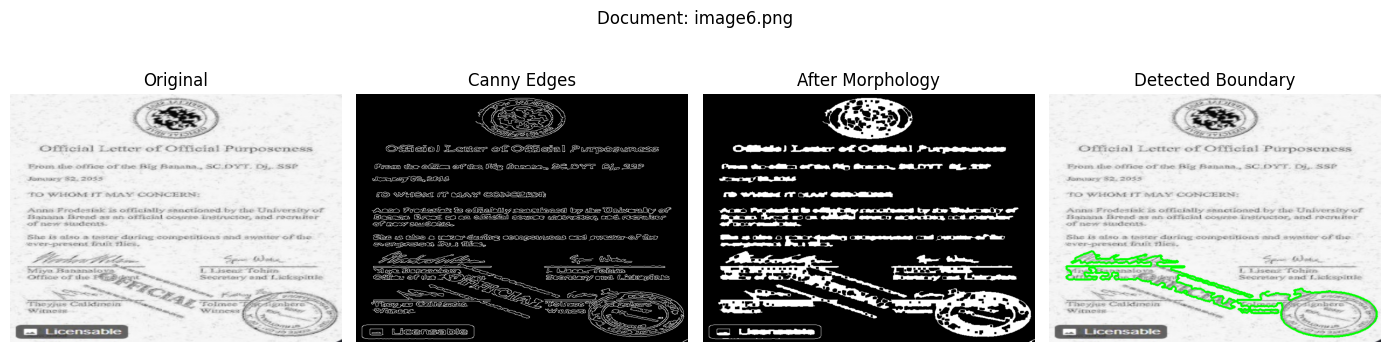

Processed: image6.png -> saved to output/detected_image6.png


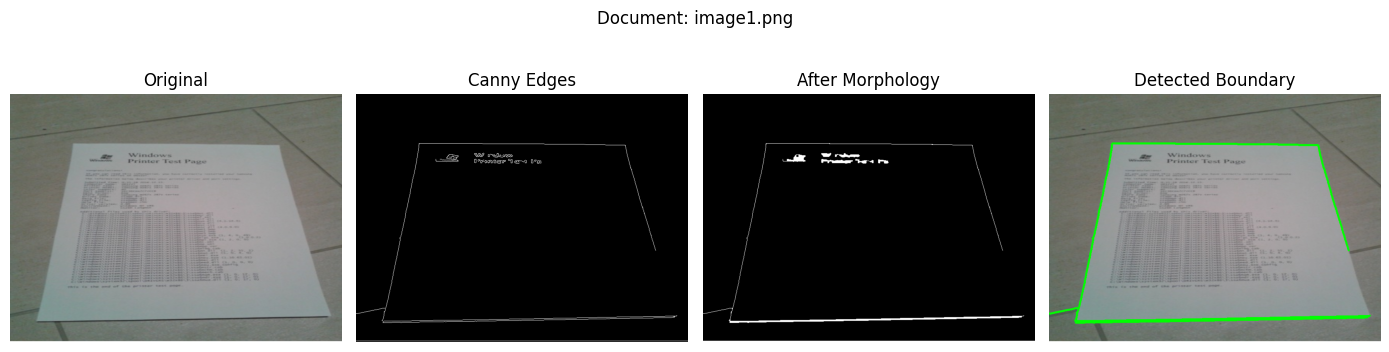

Processed: image1.png -> saved to output/detected_image1.png


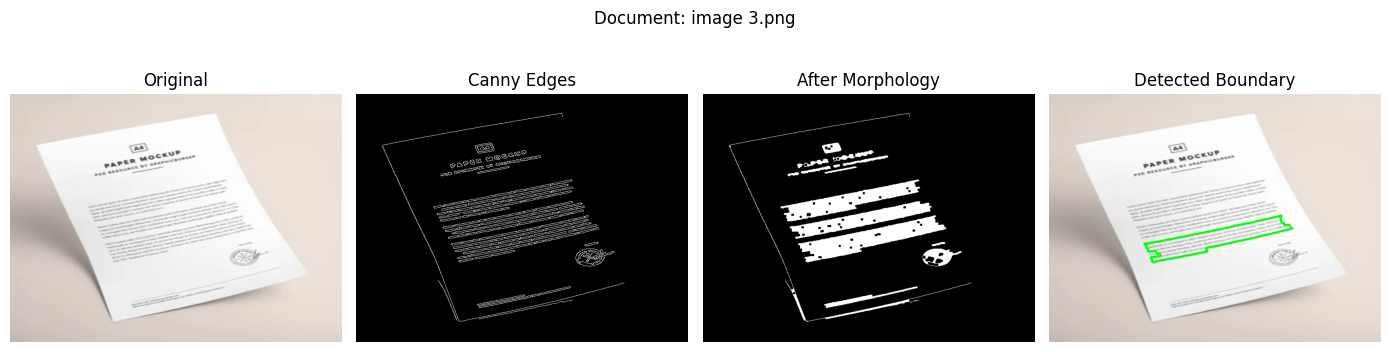

Processed: image 3.png -> saved to output/detected_image 3.png


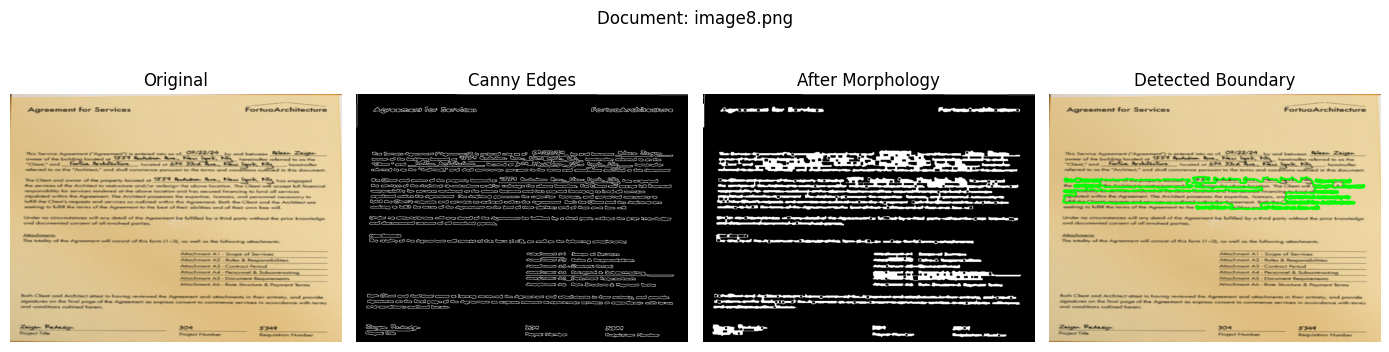

Processed: image8.png -> saved to output/detected_image8.png


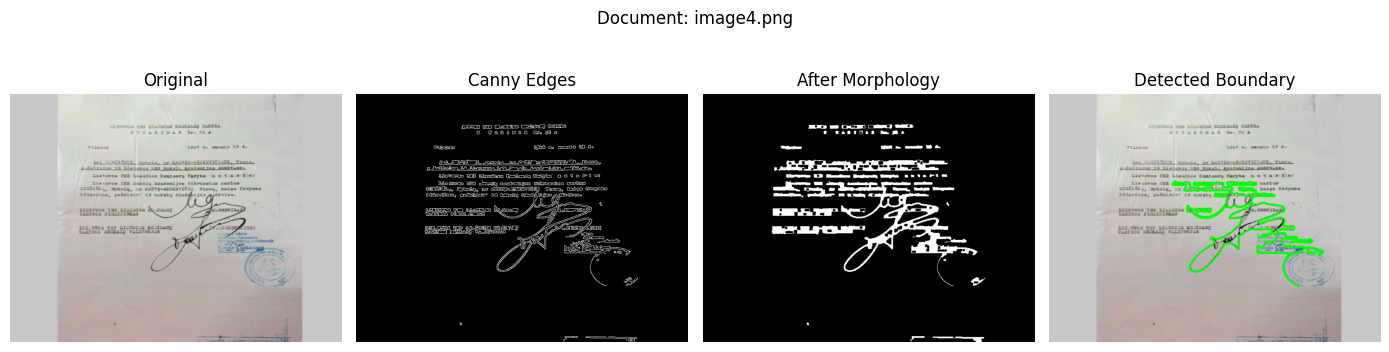

Processed: image4.png -> saved to output/detected_image4.png
All images processed.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("output", exist_ok=True)

image_folder = "/content/documents"
image_files = []

for filename in os.listdir(image_folder):
    if filename.endswith(".jpg") or filename.endswith(".jpeg") or filename.endswith(".png"):
        image_files.append(filename)

for filename in image_files:

    image_path = os.path.join(image_folder, filename)
    image = cv2.imread(image_path)
    image = cv2.resize(image, (800, 600))

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    edges = cv2.Canny(blurred, 50, 150)

    kernel = np.ones((5, 5), np.uint8)
    morphed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    contours, hierarchy = cv2.findContours(morphed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    result = image.copy()

    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(result, [largest_contour], -1, (0, 255, 0), 3)

    output_path = os.path.join("output", "detected_" + filename)
    cv2.imwrite(output_path, result)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14, 4))
    plt.suptitle("Document: " + filename, fontsize=12)

    plt.subplot(1, 4, 1)
    plt.imshow(image_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(edges, cmap="gray")
    plt.title("Canny Edges")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(morphed, cmap="gray")
    plt.title("After Morphology")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(result_rgb)
    plt.title("Detected Boundary")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Processed: " + filename + " -> saved to output/detected_" + filename)

print("All images processed.")